# Kernel diagnostic and automatic fix

This notebook contains a helper cell (right below) that will:

1. Print the active Python interpreter path and versions.
2. Check for and install `ipykernel` if it's missing.
3. Register a kernelspec named `Python (demandsense-ai)` for this interpreter.
4. Print available kernel specs.

Run the next cell (Cell 2) to perform the diagnostics and installation. After it finishes, reload VS Code (Command Palette -> Reload Window) and then use the kernel selector in the notebook editor to choose "Python (demandsense-ai)" if it appears.

In [6]:
print(0)

0


In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/PJM_Load_hourly.csv")

print("Shape:", df.shape)

df.head()

Shape: (32896, 2)


,Datetime,PJM_Load_MW
0,1998-12-31 01:00:00,29309.0
1,1998-12-31 02:00:00,28236.0
2,1998-12-31 03:00:00,27692.0
3,1998-12-31 04:00:00,27596.0
4,1998-12-31 05:00:00,27888.0


In [ ]:
print("DemandSense AI is working!")

DemandSense AI is working!


In [ ]:
import pandas as pd

df = pd.read_csv("../data/raw/PJM_Load_hourly.csv")

df.head()


,Datetime,PJM_Load_MW
0,1998-12-31 01:00:00,29309.0
1,1998-12-31 02:00:00,28236.0
2,1998-12-31 03:00:00,27692.0
3,1998-12-31 04:00:00,27596.0
4,1998-12-31 05:00:00,27888.0


In [ ]:
print("VS Code is working!")

In [ ]:
# Cell 2: Kernel diagnostic and installer
import sys
import subprocess
import json
import shutil

print('Python executable:', sys.executable)
print('Python version:', sys.version)

# Check if ipykernel is importable
try:
    import ipykernel
    print('ipykernel is installed, version:', ipykernel.__version__)
except Exception as e:
    print('ipykernel not available:', e)
    print('Attempting to install ipykernel into the current environment...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'ipykernel'])
    import ipykernel
    print('Installed ipykernel, version:', ipykernel.__version__)

# Register a kernelspec called 'Python (demandsense-ai)' for this interpreter
kernel_name = 'demandsense-ai'
display_name = 'Python (demandsense-ai)'

# Use ipykernel to install
try:
    from ipykernel.kernelspec import install
    install(kernel_name, user=True, replace=True, display_name=display_name)
    print(f'Registered kernel: {display_name} (name={kernel_name})')
except Exception as e:
    print('Failed to register kernel via ipykernel.kernelspec.install:', e)
    print('Attempting fallback to ipykernel command-line install...')
    try:
        subprocess.check_call([sys.executable, '-m', 'ipykernel', 'install', '--user', '--name', kernel_name, '--display-name', display_name])
        print('Kernel registered via ipykernel command')
    except Exception as e2:
        print('Fallback install failed:', e2)

# List installed kernel specs
try:
    from jupyter_client.kernelspec import KernelSpecManager
    ksm = KernelSpecManager()
    specs = ksm.find_kernel_specs()
    print('\nAvailable kernels:')
    print(json.dumps(specs, indent=2))
except Exception as e:
    print('Could not list kernels:', e)

# Print path of kernelspecs
ks_path = shutil.which('jupyter-kernelspec')
print('jupyter-kernelspec executable:', ks_path)

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32896 entries, 0 to 32895
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Datetime     32896 non-null  str    
 1   PJM_Load_MW  32896 non-null  float64
dtypes: float64(1), str(1)
memory usage: 514.1 KB


In [3]:
df.describe()

,PJM_Load_MW
count,32896.000000
mean,29766.427408
std,5849.769954
min,17461.000000
25%,25473.000000
50%,29655.000000
75%,33073.250000
max,54030.000000


In [4]:
df.isnull().sum()

Datetime       0
PJM_Load_MW    0
dtype: int64

In [5]:
df["Datetime"] = pd.to_datetime(df["Datetime"])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32896 entries, 0 to 32895
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Datetime     32896 non-null  datetime64[us]
 1   PJM_Load_MW  32896 non-null  float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 514.1 KB


In [6]:
df.set_index("Datetime", inplace=True)

df.head()

,PJM_Load_MW
Datetime,
1998-12-31 01:00:00,29309.0
1998-12-31 02:00:00,28236.0
1998-12-31 03:00:00,27692.0
1998-12-31 04:00:00,27596.0
1998-12-31 05:00:00,27888.0


In [7]:
print("Start Date:", df.index.min())
print("End Date:", df.index.max())

Start Date: 1998-04-01 01:00:00
End Date: 2002-01-01 00:00:00


Matplotlib is building the font cache; this may take a moment.


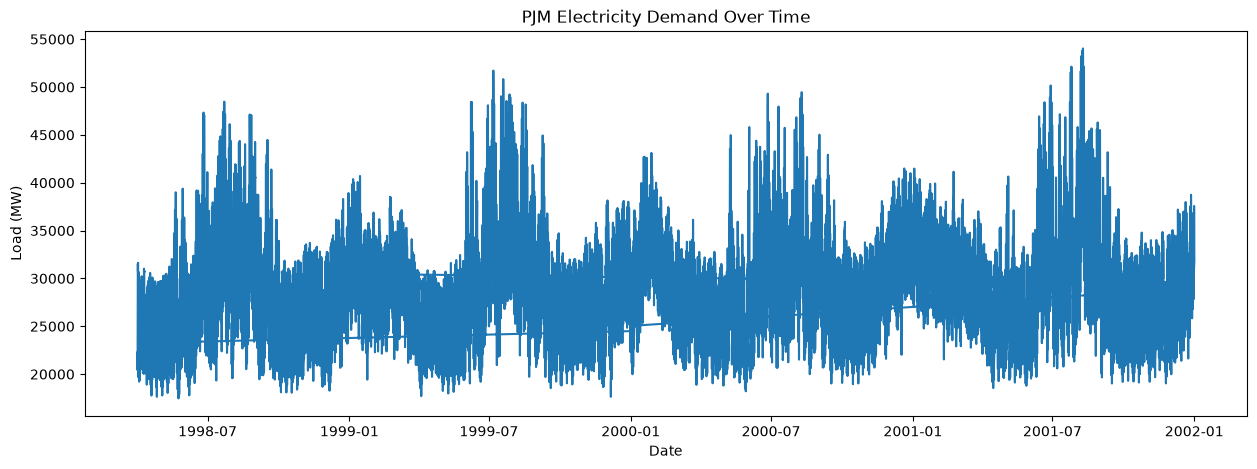

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(df["PJM_Load_MW"])
plt.title("PJM Electricity Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Load (MW)")
plt.show()

In [9]:
df["hour"] = df.index.hour
df["dayofweek"] = df.index.dayofweek
df["month"] = df.index.month
df["year"] = df.index.year

df.head()

,PJM_Load_MW,hour,dayofweek,month,year
Datetime,,,,,
1998-12-31 01:00:00,29309.0,1,3,12,1998
1998-12-31 02:00:00,28236.0,2,3,12,1998
1998-12-31 03:00:00,27692.0,3,3,12,1998
1998-12-31 04:00:00,27596.0,4,3,12,1998
1998-12-31 05:00:00,27888.0,5,3,12,1998


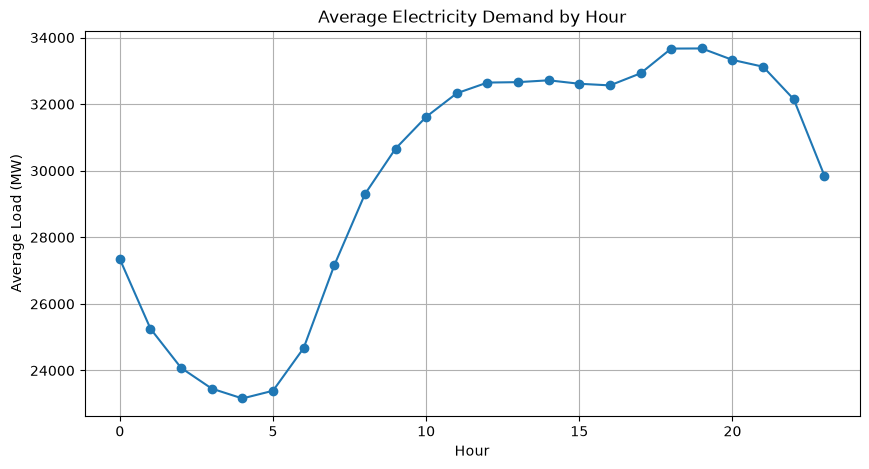

In [10]:
hourly_avg = df.groupby("hour")["PJM_Load_MW"].mean()

plt.figure(figsize=(10,5))
plt.plot(hourly_avg.index, hourly_avg.values, marker="o")
plt.title("Average Electricity Demand by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Load (MW)")
plt.grid(True)
plt.show()

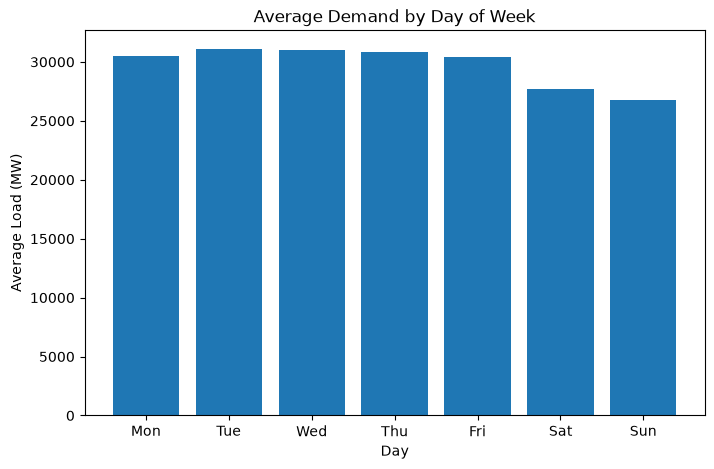

In [11]:
weekday_avg = df.groupby("dayofweek")["PJM_Load_MW"].mean()

plt.figure(figsize=(8,5))
plt.bar(
    ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"],
    weekday_avg.values
)

plt.title("Average Demand by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Load (MW)")
plt.show()

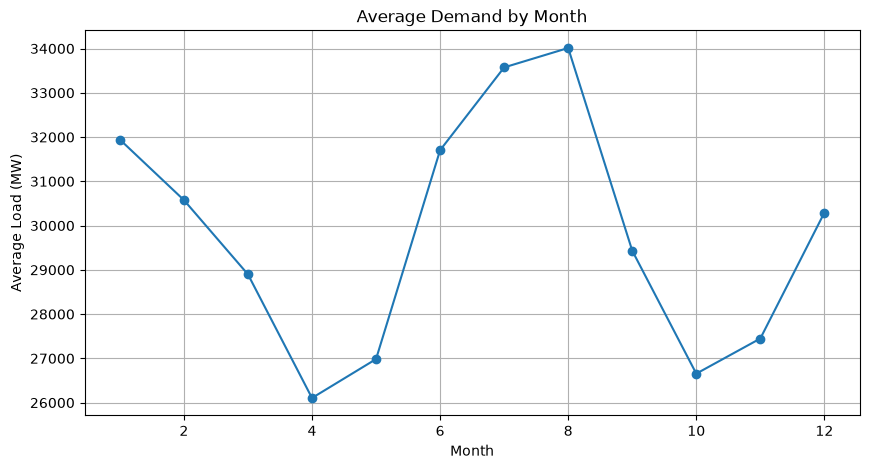

In [12]:
monthly_avg = df.groupby("month")["PJM_Load_MW"].mean()

plt.figure(figsize=(10,5))
plt.plot(monthly_avg.index, monthly_avg.values, marker="o")
plt.title("Average Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average Load (MW)")
plt.grid(True)
plt.show()

In [13]:
df["hour"] = df["Datetime"].dt.hour
df["dayofweek"] = df["Datetime"].dt.dayofweek
df["month"] = df["Datetime"].dt.month
df["year"] = df["Datetime"].dt.year

df.head()

KeyError: 'Datetime'

In [14]:
print(df.columns)

Index(['PJM_Load_MW', 'hour', 'dayofweek', 'month', 'year'], dtype='str')


In [15]:
df.head()

,PJM_Load_MW,hour,dayofweek,month,year
Datetime,,,,,
1998-12-31 01:00:00,29309.0,1,3,12,1998
1998-12-31 02:00:00,28236.0,2,3,12,1998
1998-12-31 03:00:00,27692.0,3,3,12,1998
1998-12-31 04:00:00,27596.0,4,3,12,1998
1998-12-31 05:00:00,27888.0,5,3,12,1998


In [17]:
from sklearn.model_selection import train_test_split

X = df[["hour", "dayofweek", "month", "year"]]
y = df["PJM_Load_MW"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (26316, 4)
Test : (6580, 4)


In [19]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("MAE:", round(mae, 2))
print("R² Score:", round(r2, 4))

MAE: 2211.65
R² Score: 0.7167
